# Phase 5: Customer Churn Prediction

In this phase, we build a machine learning model to predict
customer churn based on behavioral and transactional features.

Objectives:
- Define churn using purchase inactivity
- Validate and clean modeling data
- Handle missing values appropriately
- Train and evaluate classification models
- Identify key drivers of churn

In [19]:
# ============================================
# 1. Imports
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

pd.set_option('display.max_columns', None)

In [20]:
# ============================================
# 2. Load Customer Dataset
# ============================================

customer_df = pd.read_csv("../data/processed/customer_dataset.csv")

print("Dataset Shape:", customer_df.shape)
customer_df.head()

Dataset Shape: (99441, 8)


,customer_id,recency_days,frequency,monetary,total_orders,avg_order_value,max_order_value,avg_review_score
0,00012a2ce6f8dcda20d059ce98491703,338,1,114.74,1,114.74,114.74,1.0
1,000161a058600d5901f007fab4c27140,459,1,67.41,1,67.41,67.41,4.0
2,0001fd6190edaaf884bcaf3d49edf079,597,1,195.42,1,195.42,195.42,5.0
3,0002414f95344307404f0ace7a26f1d5,428,1,179.35,1,179.35,179.35,5.0
4,000379cdec625522490c315e70c7a9fb,199,1,107.01,1,107.01,107.01,4.0


## Data Quality Check

Before modeling, we verify:
- Missing values
- Data types
- Basic dataset structure

Ensuring clean inputs prevents biased models.

In [23]:
# ============================================
# 3. Missing Value Analysis
# ============================================

missing_summary = customer_df.isnull().sum()

missing_summary[missing_summary > 0] # all missing columns 

avg_order_value       1
max_order_value       1
avg_review_score    768
dtype: int64

In [25]:
customer_df.fillna({
    'avg_order_value': customer_df['avg_order_value'].median(),
    'max_order_value': customer_df['max_order_value'].median()
}, inplace=True)

In [29]:
customer_df.isna().sum()

customer_id         0
recency_days        0
frequency           0
monetary            0
total_orders        0
avg_order_value     0
max_order_value     0
avg_review_score    0
dtype: int64

## Define Churn Label

Since explicit churn labels are unavailable, we define churn
based on customer inactivity.

A customer is considered churned if their last purchase
occurred more than 90 days ago.

In [31]:
# ============================================
# 5. Create Churn Target Variable
# ============================================

churn_threshold = 90

customer_df['churn'] = np.where(
    customer_df['recency_days'] > churn_threshold,
    1, #if yes = churn 
    0  # else = no 
)

customer_df['churn'].value_counts()

churn
1    89912
0     9529
Name: count, dtype: int64

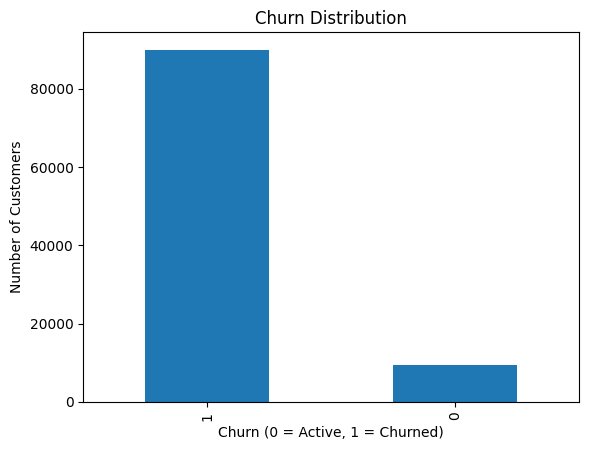

In [32]:
plt.figure()

customer_df['churn'].value_counts().plot(kind='bar')

plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

## Feature Selection

We select customer behavioral metrics
as predictors for churn modeling.

In [33]:
# ============================================
# 6. Feature Selection
# ============================================

features = customer_df[
    [
        'recency_days',
        'frequency',
        'monetary',
        'avg_order_value',
        'avg_review_score'
    ]
]

target = customer_df['churn']

features.head()

,recency_days,frequency,monetary,avg_order_value,avg_review_score
0,338,1,114.74,114.74,1.0
1,459,1,67.41,67.41,4.0
2,597,1,195.42,195.42,5.0
3,428,1,179.35,179.35,5.0
4,199,1,107.01,107.01,4.0


In [34]:
# ============================================
# 7. Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (79552, 5)
Test Shape: (19889, 5)


In [35]:
# ============================================
# 8. Feature Scaling
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Logistic Regression

Logistic Regression serves as a baseline model
for churn classification.

In [37]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.9978882799537433

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1938
           1       1.00      1.00      1.00     17951

    accuracy                           1.00     19889
   macro avg       0.99      1.00      0.99     19889
weighted avg       1.00      1.00      1.00     19889



In [39]:
cm = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 1938     0]
 [   42 17909]]


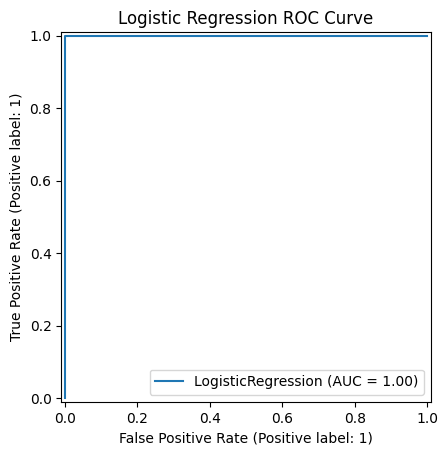

In [40]:
RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.title("Logistic Regression ROC Curve")
plt.show()

## Model 2: Random Forest

Random Forest captures nonlinear relationships
and interactions between features.

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1938
           1       1.00      1.00      1.00     17951

    accuracy                           1.00     19889
   macro avg       1.00      1.00      1.00     19889
weighted avg       1.00      1.00      1.00     19889



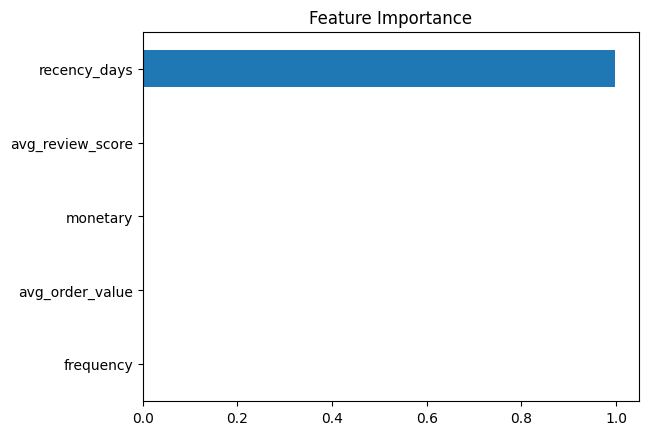

In [43]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=features.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

# Churn Modeling Insights

Key findings:

- Recency is the strongest predictor of churn.
- Customers with low purchase frequency are
  more likely to become inactive.
- Higher spending customers tend to remain engaged.

Business Recommendations:

- Monitor customers with increasing recency.
- Trigger retention campaigns early.
- Provide incentives for repeat purchases.

## Business Actions

Companies can use this model to:

identify customers likely to churn

send retention offers

create loyalty programs

re-engage inactive customers